In [4]:
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
# from moc.models.mixture.mixture_model import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import multivariate_energy_score, pce
import torch
import pickle

In [5]:
config = get_config()
config.device = 'cpu'
M = 100
alphas = torch.linspace(0, 1, M, device=config.device)

In [ ]:
seeds = [0, 42, 866, 12, 4]
rc = RunConfig(config, 'camehl', 'households')
pce_over_seeds = []
for seed in seeds:
    datamodule = RealDataModule(rc, seed=seed)
    p, q = datamodule.input_dim, datamodule.output_dim
    model = GaussianLightningModule(p,q)
    #model = MQF2LightningModule(p, q)
    trainer = get_lightning_trainer(rc)
    trainer.fit(model, datamodule)
    pces = []
    with torch.no_grad():
        model.eval()
        for x, y in datamodule.val_dataloader():
            x = x.to(config.device)
            y = y.to(config.device)
            dist = model.predict(x)
            pces.append(pce(dist, y, mode = 'all', prerank = 'dependency'))
    pce_over_seeds.append(np.array(pces).mean(axis=0))
pce_over_seeds = np.array(pce_over_seeds)

In [4]:
pce_over_seeds

array([[0.03239708],
       [0.04285899],
       [0.04282881],
       [0.03344462],
       [0.02882855]])

In [5]:
average_pce = pce_over_seeds.mean(axis=0)
stderr_pce = pce_over_seeds.std(axis=0, ddof = 1) / np.sqrt(5)
print(average_pce)
print(stderr_pce)

[0.03607161]
[0.00286874]


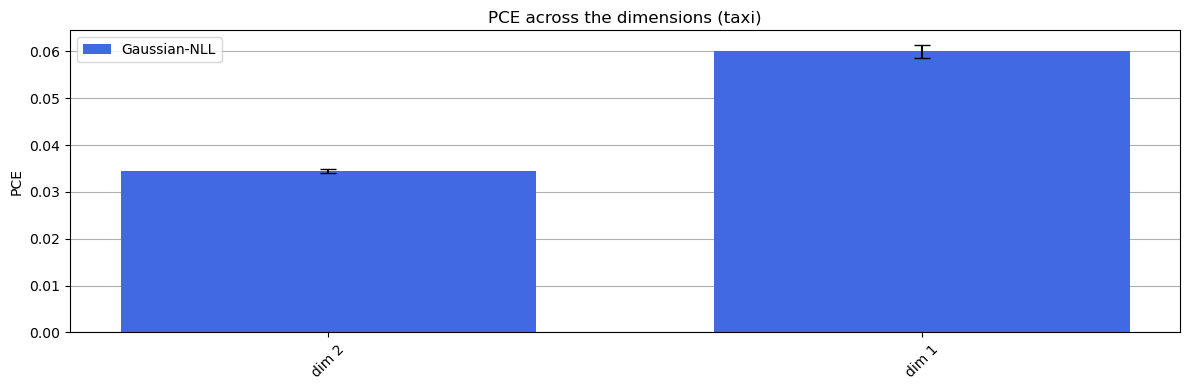

In [43]:
#plotting along PCAs
sorted_indices = np.argsort(average_pce)
sorted_means = [average_pce[i] for i in sorted_indices]
sorted_stderr = [stderr_pce[i] for i in sorted_indices]
sorted_names = [f"dim {i+1}" for i in sorted_indices]
# Step 3: Plot
x = np.arange(len(sorted_names))
#colors: royalblue, darkorange, darkorhcid
plt.figure(figsize=(12, 4))
plt.bar(x, sorted_means, width = 0.7, yerr=sorted_stderr, capsize = 6, 
        color='royalblue', label='Gaussian-NLL', zorder = 2)
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the dimensions (taxi)")
plt.legend()
plt.grid(True, axis='y', zorder = 1)
plt.tight_layout()
plt.savefig("figures/pce_taxi.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
dataset_names = [
    # ['camehl', 'households'],
    #              ['mulan', 'scm20d'],
    #              ['mulan', 'rf2'],
    #              ['mulan', 'rf1'],
    #              ['mulan', 'scm1d'],
    #              ['feldman', 'meps_21'],
    #              ['feldman', 'meps_19'],
    #              ['feldman', 'meps_20'],
    #              ['feldman', 'house'],
    #              ['feldman', 'bio'],
    #              ['feldman', 'blog_data'],
                 ['del_barrio', 'calcofi'],
                 ['wang', 'taxi']
                 ]
seeds = [0, 42, 866, 12, 4]
pces_across_datasets = {}

for dataset in dataset_names:
    data_group, data_name = dataset
    print(f"Working on dataset {data_name}")
    pce_over_seeds = pce_per_dataset(config, data_group, data_name, seeds)
    pces_across_datasets[f'{data_name}'] = np.array(pce_over_seeds)

In [2]:
with open("pce_across_dataset.pkl", "rb") as f:
    pces = pickle.load(f)
with open("pce_calcofi_taxi.pkl", "rb") as f:
    rem_pces = pickle.load(f)

In [8]:
datasets = list(pces.keys())
mean_pces = []
stderr_pces = []
for data in datasets:
    avg = pces[data].mean(axis=0)
    stderr = pces[data].std(axis=0, ddof = 1) / np.sqrt(pces[data].shape[0])
    mean_pces.append(avg)
    stderr_pces.append(stderr)

In [9]:
means = [
    np.array([arr[i] for arr in mean_pces if len(arr) > i])
    for i in range(3)
]
stderrs = [
    np.array([arr[i] for arr in stderr_pces if len(arr) > i])
    for i in range(3)
]

In [18]:
stderrs

[array([0.00276583, 0.00320345, 0.00744775, 0.00755538, 0.00837753,
        0.00353074, 0.00956032, 0.00614453, 0.00113997, 0.00050129,
        0.00063309]),
 array([0.0010815 , 0.00206451, 0.01206009, 0.00737667, 0.00422351,
        0.00421025, 0.00934299, 0.00796526, 0.00074237, 0.00297794,
        0.00090632]),
 array([0.00300147, 0.00073354, 0.00982953, 0.00429497, 0.00547519])]

In [11]:
means

[array([0.01333317, 0.0181701 , 0.05732545, 0.04548757, 0.02902651,
        0.02254424, 0.02727342, 0.0283037 , 0.00891079, 0.00721153,
        0.01447016, 0.00453231, 0.0069237 ]),
 array([0.01202008, 0.01819013, 0.04038795, 0.02709324, 0.02347165,
        0.02722137, 0.03090989, 0.03409117, 0.00995069, 0.01200214,
        0.01775695, 0.00455641, 0.00807783]),
 array([0.01183166, 0.02057567, 0.04046879, 0.04162629, 0.03306437])]

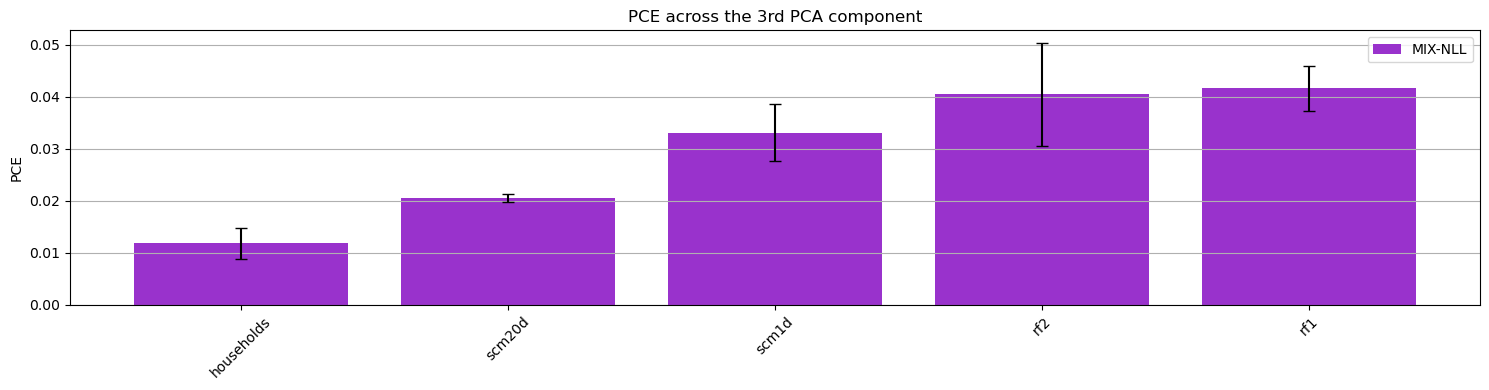

In [16]:
#plotting along PCAs
sorted_indices = np.argsort(means[2])
sorted_names = [datasets[i] for i in sorted_indices]
sorted_means = [means[2][i] for i in sorted_indices]
sorted_stderr = [stderrs[2][i] for i in sorted_indices]

# Step 3: Plot
x = np.arange(len(sorted_names))
#colors: royalblue, darkorange, darkorhcid
plt.figure(figsize=(15, 4))
plt.bar(x, sorted_means, yerr=sorted_stderr, capsize=4, color='darkorchid', label='MIX-NLL')
plt.xticks(x, sorted_names, rotation=45)
plt.ylabel("PCE")
plt.title("PCE across the 3rd PCA component")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("figures/pce_d3.png", dpi=300, bbox_inches='tight')
plt.show()

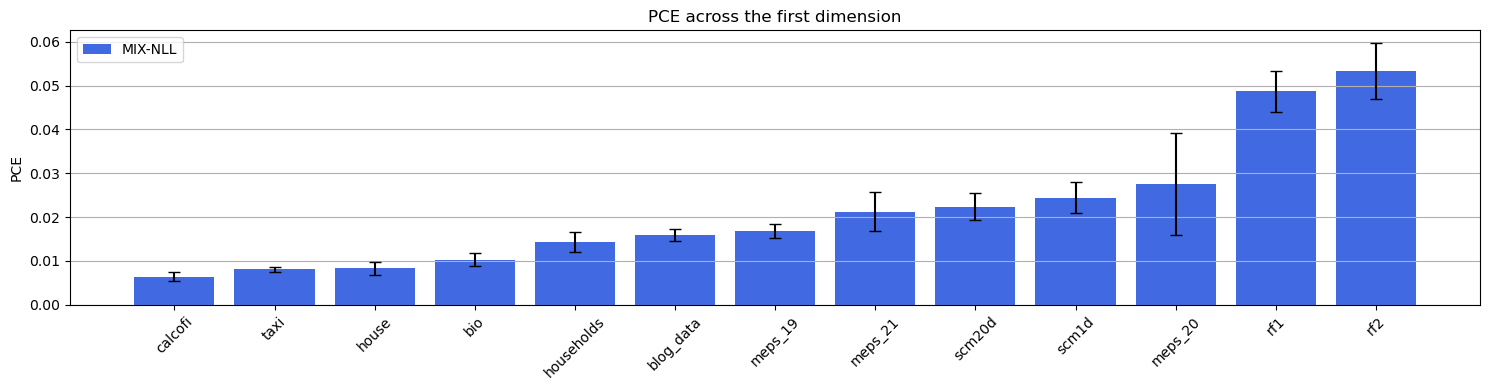

In [ ]:
dataset_names = list(pce_across_datasets.keys())
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

# Step 2: Sort everything by mean PCE


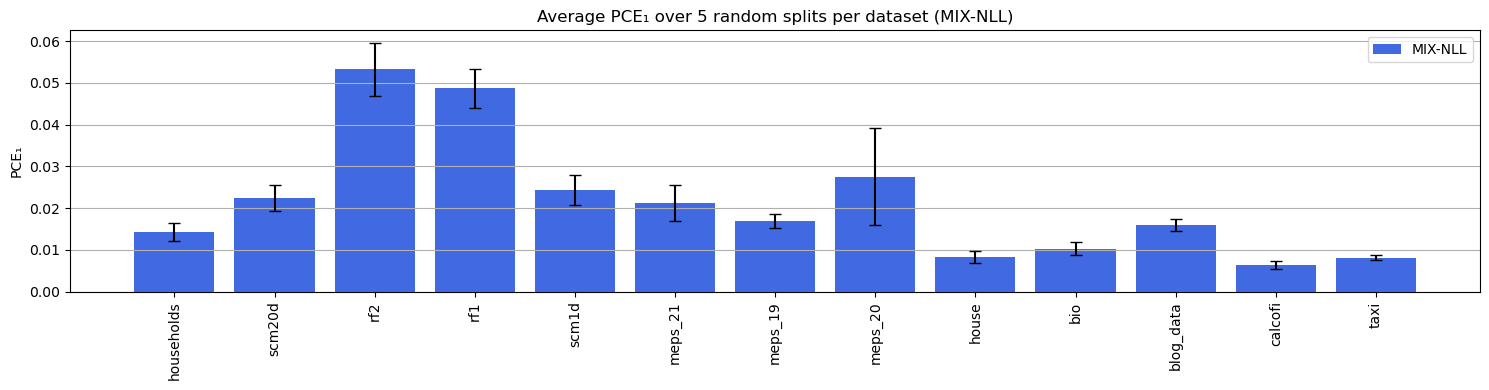

In [ ]:
# Sort dataset names alphabetically (or however you prefer)
dataset_names = pce_across_datasets.keys()

# Compute mean and standard error
mean_pces = [np.mean(pce_across_datasets[name]) for name in dataset_names]
stderr_pces = [np.std(pce_across_datasets[name], ddof=1) / np.sqrt(5) for name in dataset_names]

x = np.arange(len(dataset_names))

plt.figure(figsize=(15, 4))
plt.bar(x, mean_pces, yerr=stderr_pces, capsize=4, color='royalblue', label='MIX-NLL')
# plt.axhline(y=1/12, color='orange', linestyle='--', label='Perfect Calibration (PCE = 1/12)')
plt.xticks(x, dataset_names, rotation=90)
plt.ylabel("PCE")
plt.title("Average PCE over 5 random splits per dataset (MIX-NLL)")
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()